In [8]:
%pip install pandas matplotlib seaborn duckdb


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização para o pandas
pd.set_option('display.max_columns', None)

# Conectando ao Lakehouse
con = duckdb.connect(
    "../duckdb/lakehouse.duckdb",
    read_only=True
)
print("Conexão estabelecida com sucesso!")

Conexão estabelecida com sucesso!


In [10]:
# Listar tabelas e schemas disponíveis
df_tables = con.sql("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    ORDER BY table_schema, table_name
""").df()

display(df_tables)

,table_schema,table_name
0,bronze,despesas_funcional_programatica
1,bronze,despesas_por_orgao
2,ouro,despesas_funcional_programatica
3,ouro,despesas_por_orgao
4,prata,stg_despesas_funcional_programatica
5,prata,stg_despesas_por_orgao


In [11]:
print("--- Estrutura de 'despesas_por_orgao' ---")
display(con.sql("DESCRIBE ouro.despesas_por_orgao").df())

print("\n--- Estatísticas e Qualidade dos Dados ---")
display(con.sql("SUMMARIZE ouro.despesas_por_orgao").df())

print("\n--- Amostra dos dados (Primeiras 5 linhas) ---")
display(con.sql("SELECT * FROM ouro.despesas_por_orgao LIMIT 5").df())

--- Estrutura de 'despesas_por_orgao' ---


,column_name,column_type,null,key,default,extra
0,ano,INTEGER,YES,None,None,None
1,codigo_orgao,VARCHAR,YES,None,None,None
2,nome_orgao,VARCHAR,YES,None,None,None
3,codigo_orgao_superior,VARCHAR,YES,None,None,None
4,nome_orgao_superior,VARCHAR,YES,None,None,None
5,pacote,VARCHAR,YES,None,None,None
6,fl_ano_eleitoral,BOOLEAN,YES,None,None,None
7,tipo_eleicao,VARCHAR,YES,None,None,None
8,fl_ano_pre_eleitoral,BOOLEAN,YES,None,None,None
9,fl_ano_pos_eleitoral,BOOLEAN,YES,None,None,None



--- Estatísticas e Qualidade dos Dados ---


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,ano,INTEGER,2014,2026,15,2020.004222972973,3.7461687382680284,2017,2020,2023,2368,0.00
1,codigo_orgao,VARCHAR,20101,74919,168,NaN,NaN,NaN,NaN,NaN,2368,0.00
2,nome_orgao,VARCHAR,AUTORIDADE NACIONAL DE SEGURANCA NUCLEAR,"VALEC Engenharia, Construções e Ferrovias S.A.",209,NaN,NaN,NaN,NaN,NaN,2368,0.00
3,codigo_orgao_superior,VARCHAR,20000,56000,13,NaN,NaN,NaN,NaN,NaN,2368,0.00
4,nome_orgao_superior,VARCHAR,Ministério da Educação,Presidência da República,11,NaN,NaN,NaN,NaN,NaN,2368,0.00
5,pacote,VARCHAR,coordenacao_politica,nucleo_eleitoral,3,NaN,NaN,NaN,NaN,NaN,2368,0.00
6,fl_ano_eleitoral,BOOLEAN,false,true,2,NaN,NaN,NaN,NaN,NaN,2368,0.00
7,tipo_eleicao,VARCHAR,geral,municipal,2,NaN,NaN,NaN,NaN,NaN,2368,46.03
8,fl_ano_pre_eleitoral,BOOLEAN,false,true,2,NaN,NaN,NaN,NaN,NaN,2368,8.11
9,fl_ano_pos_eleitoral,BOOLEAN,false,true,2,NaN,NaN,NaN,NaN,NaN,2368,8.11



--- Amostra dos dados (Primeiras 5 linhas) ---


,ano,codigo_orgao,nome_orgao,codigo_orgao_superior,nome_orgao_superior,pacote,fl_ano_eleitoral,tipo_eleicao,fl_ano_pre_eleitoral,fl_ano_pos_eleitoral,governo,valor_empenhado,valor_liquidado,valor_pago,valor_pago_lag_1,valor_pago_lag_2,variacao_yoy_abs,variacao_yoy_pct,rolling_mean_3
0,2014,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,True,geral,<NA>,False,Dilma 1,1.135485e+09,8.773086e+08,8.205415e+08,NaN,NaN,NaN,NaN,8.205415e+08
1,2015,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,False,NaN,True,True,Dilma 2,9.562235e+08,7.963628e+08,7.804878e+08,8.205415e+08,NaN,-4.005371e+07,-4.88,8.005147e+08
2,2016,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,True,municipal,False,False,Transicao,1.055106e+09,8.470305e+08,8.349759e+08,7.804878e+08,8.205415e+08,5.448803e+07,6.98,8.120017e+08
3,2017,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,False,NaN,True,True,Temer,1.207051e+09,8.882800e+08,8.879070e+08,8.349759e+08,7.804878e+08,5.293111e+07,6.34,8.344569e+08
4,2018,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,True,geral,False,False,Temer,1.161314e+09,8.403797e+08,7.840899e+08,8.879070e+08,8.349759e+08,-1.038171e+08,-11.69,8.356576e+08


In [12]:
print("--- Estrutura de 'despesas_funcional_programatica' ---")
display(con.sql("DESCRIBE ouro.despesas_funcional_programatica").df())

print("\n--- Estatísticas e Qualidade dos Dados ---")
display(con.sql("SUMMARIZE ouro.despesas_funcional_programatica").df())

print("\n--- Amostra dos dados (Primeiras 5 linhas) ---")
display(con.sql("SELECT * FROM ouro.despesas_funcional_programatica LIMIT 5").df())

--- Estrutura de 'despesas_funcional_programatica' ---


,column_name,column_type,null,key,default,extra
0,ano,INTEGER,YES,None,None,None
1,codigo_funcao,VARCHAR,YES,None,None,None
2,nome_funcao,VARCHAR,YES,None,None,None
3,pacote,VARCHAR,YES,None,None,None
4,fl_ano_eleitoral,BOOLEAN,YES,None,None,None
5,tipo_eleicao,VARCHAR,YES,None,None,None
6,fl_ano_pre_eleitoral,BOOLEAN,YES,None,None,None
7,fl_ano_pos_eleitoral,BOOLEAN,YES,None,None,None
8,governo,VARCHAR,YES,None,None,None
9,valor_empenhado,DOUBLE,YES,None,None,None



--- Estatísticas e Qualidade dos Dados ---


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,ano,INTEGER,2014,2026,15,2020.0,3.7561319374834365,2017,2020,2023,130,0.00
1,codigo_funcao,VARCHAR,04,26,10,NaN,NaN,NaN,NaN,NaN,130,0.00
2,nome_funcao,VARCHAR,Administração,Urbanismo,11,NaN,NaN,NaN,NaN,NaN,130,0.00
3,pacote,VARCHAR,administracao_governo,seguranca_estado,4,NaN,NaN,NaN,NaN,NaN,130,0.00
4,fl_ano_eleitoral,BOOLEAN,false,true,2,NaN,NaN,NaN,NaN,NaN,130,0.00
5,tipo_eleicao,VARCHAR,geral,municipal,2,NaN,NaN,NaN,NaN,NaN,130,46.15
6,fl_ano_pre_eleitoral,BOOLEAN,false,true,2,NaN,NaN,NaN,NaN,NaN,130,7.69
7,fl_ano_pos_eleitoral,BOOLEAN,false,true,2,NaN,NaN,NaN,NaN,NaN,130,7.69
8,governo,VARCHAR,Bolsonaro,Temer,5,NaN,NaN,NaN,NaN,NaN,130,0.00
9,valor_empenhado,DOUBLE,2354613321.73,423007645585.44,147,69091042422.49355,71213585923.9038,16474722241.540003,36312200014.402504,102084023952.82997,130,0.00



--- Amostra dos dados (Primeiras 5 linhas) ---


,ano,codigo_funcao,nome_funcao,pacote,fl_ano_eleitoral,tipo_eleicao,fl_ano_pre_eleitoral,fl_ano_pos_eleitoral,governo,valor_empenhado,valor_liquidado,valor_pago,valor_pago_lag_1,valor_pago_lag_2,variacao_yoy_abs,variacao_yoy_pct,rolling_mean_3
0,2014,04,Administração,administracao_governo,True,geral,<NA>,False,Dilma 1,2.314113e+10,2.175598e+10,2.125422e+10,NaN,NaN,NaN,NaN,2.125422e+10
1,2015,04,Administração,administracao_governo,False,NaN,True,True,Dilma 2,2.367990e+10,2.262870e+10,2.099681e+10,2.125422e+10,NaN,-2.574142e+08,-1.21,2.112551e+10
2,2016,04,Administração,administracao_governo,True,municipal,False,False,Dilma 2,2.656063e+10,2.496540e+10,2.319428e+10,2.099681e+10,2.125422e+10,2.197475e+09,10.47,2.181510e+10
3,2017,04,Administração,administracao_governo,False,NaN,True,True,Temer,2.937128e+10,2.761636e+10,2.657492e+10,2.319428e+10,2.099681e+10,3.380638e+09,14.58,2.358867e+10
4,2018,04,Administração,administracao_governo,True,geral,False,False,Temer,3.317010e+10,3.112360e+10,2.839832e+10,2.657492e+10,2.319428e+10,1.823401e+09,6.86,2.605584e+10


In [13]:
# ==========================================
# 1. RESUMO TEMPORAL E VOLUMETRIA (AMBAS AS TABELAS)
# ==========================================
df_tempo = con.sql("""
    SELECT 
        'despesas_por_orgao' as tabela,
        MIN(ano) as primeiro_ano,
        MAX(ano) as ultimo_ano,
        COUNT(DISTINCT ano) as total_anos_cobertos,
        COUNT(*) as total_registros
    FROM ouro.despesas_por_orgao

    UNION ALL

    SELECT 
        'despesas_funcional_programatica' as tabela,
        MIN(ano) as primeiro_ano,
        MAX(ano) as ultimo_ano,
        COUNT(DISTINCT ano) as total_anos_cobertos,
        COUNT(*) as total_registros
    FROM ouro.despesas_funcional_programatica
""").df()

print("--- Resumo Temporal e Volumetria Geral ---")
display(df_tempo)


# ==========================================
# 2. AGRUPAMENTOS POR ANO E PACOTE
# ==========================================

# Agrupando despesas por Órgão e por Pacote
df_orgao_pacote = con.sql("""
    SELECT 
        ano, 
        pacote,
        COUNT(*) as qtd_registros,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_por_orgao
    GROUP BY ano, pacote
    ORDER BY pacote, ano
""").df()

# Agrupando despesas Funcionais por Pacote
df_funcional_pacote = con.sql("""
    SELECT 
        ano, 
        pacote,
        COUNT(*) as qtd_registros,
        SUM(valor_pago) as total_pago
    FROM ouro.despesas_funcional_programatica
    GROUP BY ano, pacote
    ORDER BY pacote, ano
""").df()


# ==========================================
# 3. EXIBIÇÃO DOS RESULTADOS SEGMENTADOS
# ==========================================

print("\n--- Distribuição de Gastos por Órgão e Pacote ---")
display(df_orgao_pacote)

print("\n--- Distribuição de Gastos Funcional Programática por Pacote ---")
display(df_funcional_pacote)

--- Resumo Temporal e Volumetria Geral ---


,tabela,primeiro_ano,ultimo_ano,total_anos_cobertos,total_registros
0,despesas_por_orgao,2014,2026,13,2368
1,despesas_funcional_programatica,2014,2026,13,130



--- Distribuição de Gastos por Órgão e Pacote ---


,ano,pacote,qtd_registros,total_pago
0,2014,coordenacao_politica,29,1.177664e+12
1,2015,coordenacao_politica,29,1.207503e+12
2,2016,coordenacao_politica,29,1.396276e+12
3,2017,coordenacao_politica,26,1.226682e+12
4,2018,coordenacao_politica,25,1.318819e+12
5,2019,coordenacao_politica,24,1.303627e+12
6,2020,coordenacao_politica,24,1.724912e+12
7,2021,coordenacao_politica,24,2.291743e+12
8,2022,coordenacao_politica,24,2.305856e+12
9,2023,coordenacao_politica,24,2.328607e+12



--- Distribuição de Gastos Funcional Programática por Pacote ---


,ano,pacote,qtd_registros,total_pago
0,2014,administracao_governo,2,9.082578e+10
1,2015,administracao_governo,2,8.631636e+10
2,2016,administracao_governo,2,9.323674e+10
3,2017,administracao_governo,2,9.587952e+10
4,2018,administracao_governo,2,9.868747e+10
5,2019,administracao_governo,2,9.806000e+10
6,2020,administracao_governo,2,1.015991e+11
7,2021,administracao_governo,2,9.091080e+10
8,2022,administracao_governo,2,1.173758e+11
9,2023,administracao_governo,2,1.207079e+11


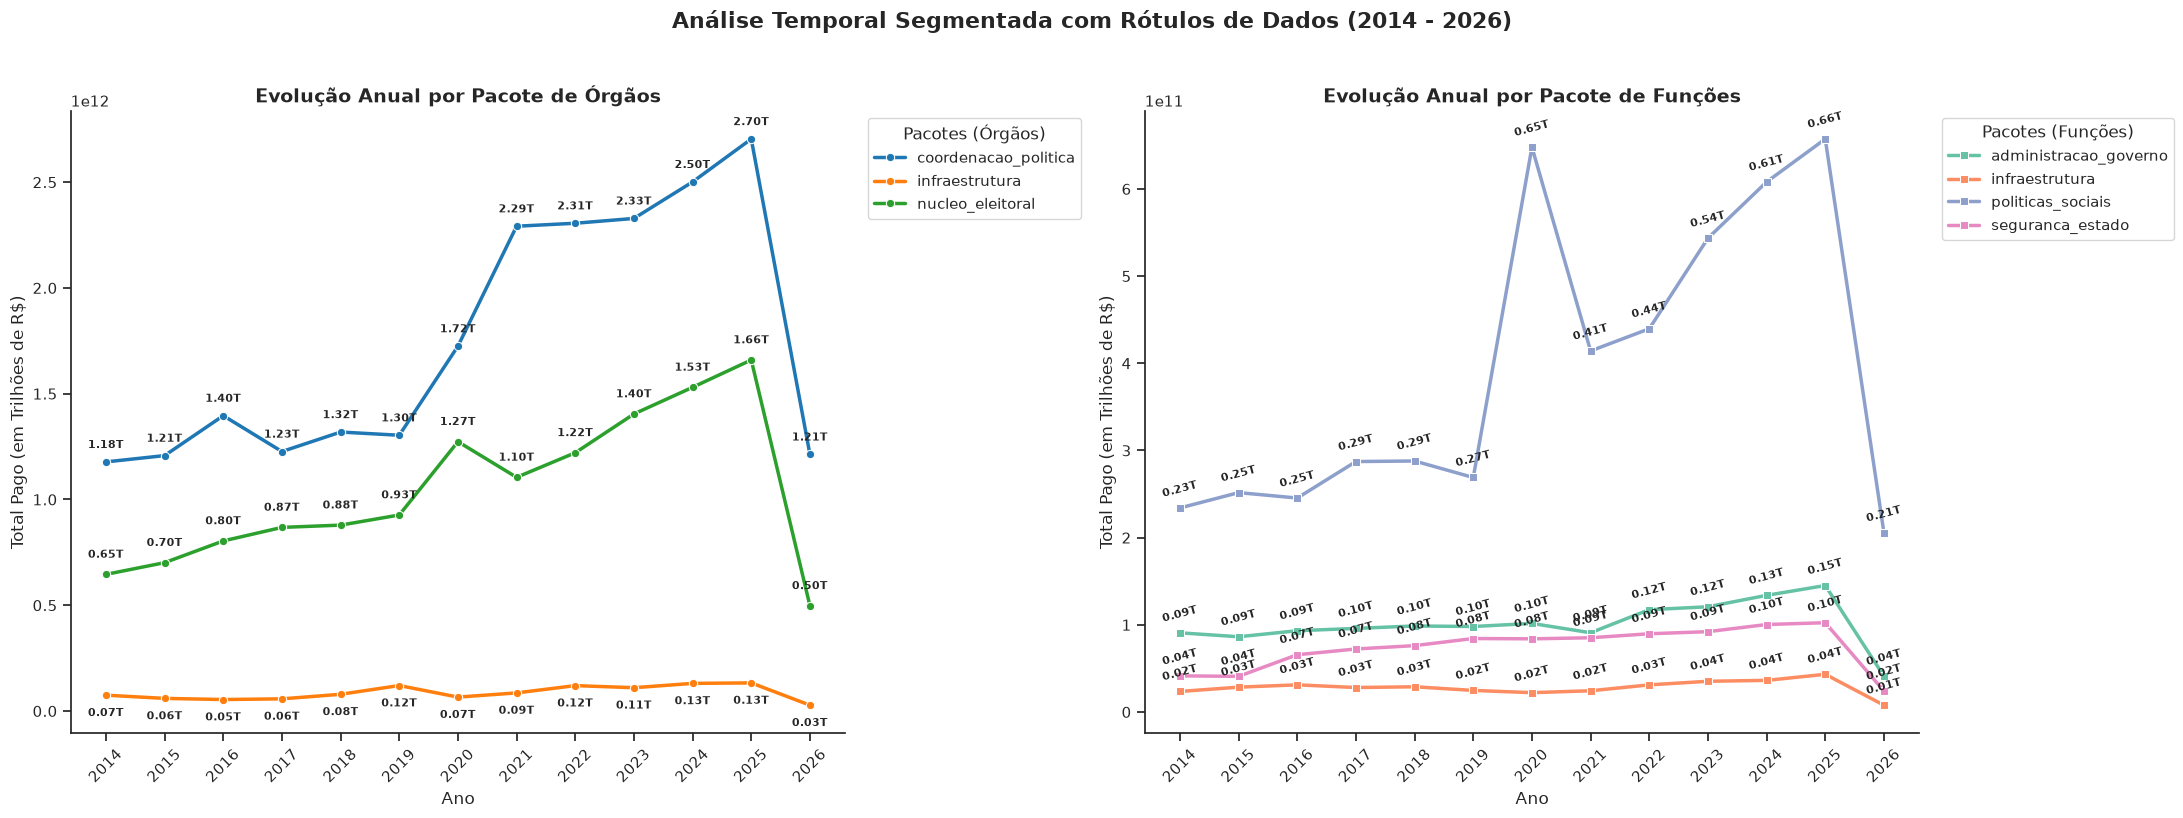

In [ ]:
sns.set_theme(style="ticks") 
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# --- Gráfico 1: Despesas por Órgão (Quebrado por Pacote) ---
sns.lineplot(
    ax=axes[0], 
    data=df_orgao_pacote, 
    x='ano', 
    y='total_pago', 
    hue='pacote', 
    marker='o', 
    linewidth=2.5,
    palette='tab10'
)
axes[0].set_title('Evolução Anual por Pacote de Órgãos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ano', fontsize=12)
axes[0].set_ylabel('Total Pago (em Trilhões de R$)', fontsize=12)
axes[0].set_xticks(df_orgao_pacote['ano'].unique())
axes[0].tick_params(axis='x', labelrotation=45)
axes[0].legend(title='Pacotes (Órgãos)', bbox_to_anchor=(1.02, 1), loc='upper left')

# Adicionando rótulos em TODOS os anos para Órgãos
# Criamos um deslocamento dinâmico para evitar que as linhas fiquem em cima uma da outra
offset_map_orgao = {"nucleo_eleitoral": 12, "infraestrutura": -15, "coordenacao_politica": 10}

for pacote in df_orgao_pacote['pacote'].unique():
    df_sub = df_orgao_pacote[df_orgao_pacote['pacote'] == pacote]
    y_offset = offset_map_orgao.get(pacote, 10)
    
    for _, row in df_sub.iterrows():
        valor_trilhao = row['total_pago'] / 1e12
        # Evita plotar labels redundantes se o valor for zero
        if valor_trilhao > 0:
            axes[0].annotate(f'{valor_trilhao:.2f}T', 
                             (row['ano'], row['total_pago']),
                             textcoords="offset points", 
                             xytext=(0, y_offset), 
                             ha='center', 
                             fontsize=8, 
                             fontweight='bold')


# --- Gráfico 2: Despesas Funcional Programática (Quebrado por Pacote) ---
sns.lineplot(
    ax=axes[1], 
    data=df_funcional_pacote, 
    x='ano', 
    y='total_pago', 
    hue='pacote', 
    marker='s', 
    linewidth=2.5,
    palette='Set2'
)
axes[1].set_title('Evolução Anual por Pacote de Funções', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano', fontsize=12)
axes[1].set_ylabel('Total Pago (em Trilhões de R$)', fontsize=12)
axes[1].set_xticks(df_funcional_pacote['ano'].unique())
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].legend(title='Pacotes (Funções)', bbox_to_anchor=(1.02, 1), loc='upper left')

for pacote in df_funcional_pacote['pacote'].unique():
    df_sub = df_funcional_pacote[df_funcional_pacote['pacote'] == pacote]
    
    for _, row in df_sub.iterrows():
        valor_trilhao = row['total_pago'] / 1e12
        if valor_trilhao > 0:
            axes[1].annotate(f'{valor_trilhao:.2f}T', 
                             (row['ano'], row['total_pago']),
                             textcoords="offset points", 
                             xytext=(0, 8), 
                             ha='center', 
                             fontsize=8, 
                             fontweight='bold',
                             rotation=15)

plt.suptitle('Análise Temporal Segmentada com Rótulos de Dados (2014 - 2026)', fontsize=16, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

# Conclusão da Etapa de Exploração de Dados

Após o mapeamento estrutural, validação volumétrica e análise visual das tabelas da camada `ouro` (`despesas_por_orgao` e `despesas_funcional_programatica`), consolidamos os seguintes aprendizados fundamentais para o projeto:

### 1. Escopo Amostral e Alinhamento com a Extração (API)
* **Estratégia de Filtro por Hipótese:** A exploração confirmou que os dados não representam o orçamento genérico e total da União. Eles refletem uma estratégia de coleta direcionada por pacotes temáticos (coluna `pacote`), isolando grupos específicos de Ministérios e Funções Orçamentárias para responder às hipóteses do projeto.
* **Volume de Registros Diferenciado:** O dataset conta com **2.368 linhas** na tabela `despesas_por_orgao` (maior detalhamento por entidades públicas) e **130 linhas** na tabela `despesas_funcional_programatica` (estrutura consolidada por macrofunções).
* **Consistência Temporal:** Ambas as visões cobrem uma série histórica robusta de **13 anos (2014 a 2026)** com distribuições anuais estáveis, o que reflete a rigidez institucional da estrutura do gasto público.

### 2. Comportamento e Justificativa das Variáveis Financeiras
* **Esclarecimento sobre a Divergência Nominal:** A quebra gráfica por pacotes solucionou a aparente diferença de valores absolutos entre as tabelas. A tabela de Órgãos rastreia estruturas de alto orçamento como `coordenação_política` (pico de R$ 2,70T em 2025) e `núcleo_eleitoral` (pico de R$ 1,66T em 2025). Já a tabela Funcional detalha classificações como `políticas_sociais` (pico de R$ 0,66T em 2025). Tratam-se, portanto, de perspectivas complementares e não redundantes.
* **Janela do Ano Corrente (2026):** A queda acentuada observada no último ponto de todas as linhas em 2026 é um comportamento natural e esperado do dado, uma vez que o ano está em curso e os valores representam apenas o acumulado parcial até o momento.

### 3. Prontidão e Próximos Passos
* **Direcionamento para o Notebook 2 (Análise de Despesas):** Com a dinâmica macro dos pacotes compreendida, estamos prontos para descer o nível de granularidade. No próximo notebook, analisaremos a correlação dos gastos com os atributos de contexto político (`fl_ano_eleitoral` e transições de `governo`), além de fatiar quais órgãos individuais lideram os gastos de cada grupo.
* **Base para o Notebook 3 (Machine Learning):** A clara diferenciação de comportamento e tendência entre os pacotes (`coordenação_política` em ascensão rápida vs. `infraestrutura` linearizado e estável) valida que as variáveis categóricas de agrupamento e os atributos de *lag* temporal possuem alto poder preditivo e guiarão com sucesso os modelos de regressão.

---
